# 02 · The money shot — naive A/B is biased under interference

**The thesis, made visible**, in two acts:

1. **The problem** (multi-advertiser market): a user-randomized A/B read as a difference-in-means is
   **biased**, and the bias **grows with treatment share**. We measure it against a ground truth we
   can only have because we authored the data-generating process.
2. **The fix, proven** (single-advertiser world): when budget cannibalization is the *only*
   interference channel, the **budget-split design recovers the true ATE exactly**.

These claims are asserted in `tests/test_naive_bias.py` and `tests/test_recovery.py`; this notebook
is the picture behind them. We pass `compute_tau=False` to the analysis runs (the truth comes from
shadow runs, not per-conversion tau) — it just makes them faster.

In [1]:
import nbtools; nbtools.use_repo_root(); nbtools.set_style()
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from engine.market import run
from engine.oracle import global_ate
from inference import naive, budget_split
from inference.base import user_outcomes
from nbtools import BLUE, GREEN, PINK, ORANGE, GRAY

EXP = "exp_reward_sizing"

## 1. The estimand — what is the *true* effect?

Write $Y_i(w)$ for user $i$'s outcome (their margin contribution) under treatment assignment $w\in
\{0,1\}$ — a **potential outcome** (Neyman/Rubin). The classic **average treatment effect** is
$\tau = \mathbb{E}[Y_i(1)-Y_i(0)]$. Crucially, this definition assumes **SUTVA** — that $i$'s outcome
depends only on $i$'s own assignment. In a marketplace that **fails**: if treated users deplete a
shared budget, a control user's outcome depends on *how many others were treated*. This is
**interference** (a.k.a. spillover), and it is the whole point of the project (Wager, *Causal
Inference*, ch. on spillovers/interference; Munro–Kuang–Wager on marketplace equilibrium —
`paper-library/notation/interference.md`).

Under interference the honest target is the **global ATE**: the gap in the OEC between a world where
**everyone** is treated and one where **everyone** is control,
$$\tau_{\text{global}} \;=\; \mathrm{OEC}(\mathbf{1}) - \mathrm{OEC}(\mathbf{0}),
  \qquad \mathrm{OEC}(\mathbf{w}) = \frac{1}{N}\sum_i Y_i(\mathbf{w}),$$
where $\mathbf{w}$ is the *whole* assignment vector (so the two worlds have different budget
scarcity, and $\tau_{\text{global}}$ *includes* the interference). You **cannot** read $\tau_{\text{
global}}$ off one partial-rollout run. Because we authored the data-generating process, we get it by
**counterfactually replaying** the engine twice on the same seed — all-control and all-treatment
(`engine/oracle.py`, `force_arm`). These are "shadow runs": the oracle the estimators never see.

### The estimators (and the libraries behind them)

A typical team estimates the effect with a **difference-in-means** at the user level — the **naive**
estimator. With treatment/control sets $T,C$ and per-user outcome $Y_i$:
$$\hat\tau_{\text{naive}} \;=\; \frac{1}{|T|}\sum_{i\in T} Y_i \;-\; \frac{1}{|C|}\sum_{i\in C} Y_i,
  \qquad
  \widehat{\mathrm{SE}} \;=\; \sqrt{\tfrac{s_T^2}{|T|}+\tfrac{s_C^2}{|C|}}\ \ (\text{Welch}).$$
It is unbiased for $\tau$ **only under SUTVA**. Under interference its probability limit is a
*contaminated* contrast — the gap we are about to measure.

- **Library:** we don't hand-roll the SEs — `inference/naive.py` uses
  **`statsmodels`** (`CompareMeans` / `DescrStatsW`, unequal-variance Welch CI). The per-user
  analysis table is built straight off the parquet event log with **`duckdb`** (`inference/base.py`);
  the dbt metrics layer (M3) will later sit in between. See `STACK.md` (use the library, don't
  re-derive the statistics).
- **The correction — budget-split.** The fix for budget cannibalization is a *design*: give each arm
  its **own budget pool** sized to its share, so neither arm starves the other. The estimator is then
  a plain difference-in-means on that design — the correction lives in *how the data was generated*.
  This is LinkedIn's **budget-split design** (Liu et al., *Trustworthy Online Marketplace
  Experimentation with Budget-split Design*); see `inference/budget_split.py` and
  `paper-library/` (platform-experimentation). We also keep a **cluster-robust** estimator
  (`inference/cluster.py`, `statsmodels` `cov_type="cluster"`) for the cluster-randomized story.

In [2]:
cfg = nbtools.market_cfg(seed=11, users=9000, days=22)
print(f"market: {cfg.market.n_advertisers} advertisers, {cfg.market.n_offers} offers, "
      f"{cfg.market.n_users_initial} users, {cfg.meta.horizon_days} days")

gt = global_ate(cfg, EXP)
print(f"\nOEC(all control)   = {gt.oec_control:+.4f}")
print(f"OEC(all treatment) = {gt.oec_treatment:+.4f}")
print(f"GLOBAL ATE (truth) = {gt.ate:+.4f}   <- richer reward trades margin for volume (net negative)")

market: 12 advertisers, 50 offers, 9000 users, 22 days



OEC(all control)   = +1.3829
OEC(all treatment) = +0.6985
GLOBAL ATE (truth) = -0.6845   <- richer reward trades margin for volume (net negative)


## 2. Act I — the problem: naive drifts with allocation

We run the experiment at several fixed **allocations** — the treatment share, e.g. 20% means a
20/80 treatment/control split. Each **arm** is a group of users: *treatment* (gets the lever) vs
*control* (baseline). We hold the allocation **constant from day 0** so the arms are a clean cohort —
as opposed to a *ramp* (gradually rising allocation), which induces a selection bias we dissect in
notebook 03. For each allocation we estimate naively and compare the estimate to the true global ATE.

In [3]:
allocations = [0.05, 0.20, 0.35, 0.50]
rows = []
for share in allocations:
    run(nbtools.fixed_alloc(cfg, share, "standard"), output_dir="events_std", compute_tau=False)
    df = user_outcomes("events_std", EXP)
    en = naive.estimate(df)
    # budget-split design at the same allocation (Act II preview — partial in the multi-channel world)
    run(nbtools.fixed_alloc(cfg, share, "budget_split"), output_dir="events_bs", compute_tau=False)
    eb = budget_split.estimate(user_outcomes("events_bs", EXP))
    rows.append(dict(share=share,
                     naive=en.point, naive_lo=en.ci_low, naive_hi=en.ci_high,
                     bs=eb.point, bs_lo=eb.ci_low, bs_hi=eb.ci_high,
                     ctrl_conv=df.loc[df.arm == "control", "n_conv"].mean(),
                     treat_conv=df.loc[df.arm == "treatment", "n_conv"].mean()))
    print(f"alloc {share:>4.0%}: naive {en.point:+.4f}  bias {en.point - gt.ate:+.4f}  "
          f"(covers truth: {en.covers(gt.ate)})")
res = pd.DataFrame(rows)

alloc   5%: naive -0.6060  bias +0.0785  (covers truth: True)


alloc  20%: naive -0.5428  bias +0.1417  (covers truth: False)


alloc  35%: naive -0.4926  bias +0.1919  (covers truth: False)


alloc  50%: naive -0.4654  bias +0.2191  (covers truth: False)


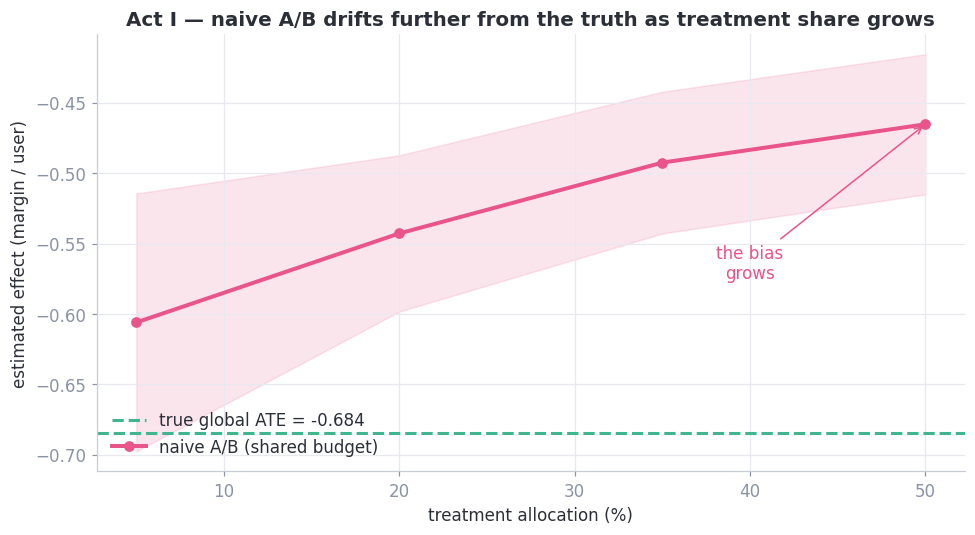

naive bias by allocation: {'5%': 0.0785, '20%': 0.1417, '35%': 0.1919, '50%': 0.2191}


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
x = res.share * 100
ax.axhline(gt.ate, color=GREEN, ls="--", lw=2, label=f"true global ATE = {gt.ate:+.3f}")
ax.fill_between(x, res.naive_lo, res.naive_hi, color=PINK, alpha=0.15)
ax.plot(x, res.naive, "-o", color=PINK, lw=2.6, label="naive A/B (shared budget)")
ax.set_xlabel("treatment allocation (%)"); ax.set_ylabel("estimated effect (margin / user)")
ax.set_title("Act I — naive A/B drifts further from the truth as treatment share grows")
ax.annotate("the bias\ngrows", xy=(50, res.naive.iloc[-1]),
            xytext=(40, (res.naive.iloc[-1] + gt.ate) / 2), color=PINK, ha="center",
            arrowprops=dict(arrowstyle="->", color=PINK))
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()

print("naive bias by allocation:",
      {f"{s:.0%}": round(n - gt.ate, 4) for s, n in zip(res.share, res.naive)})

## 3. Why — the mechanism (budget cannibalization)

Treated users (richer reward) complete the offer faster and **deplete the daily budget**, so control
users arriving later find it exhausted. The more you treat, the more the control arm is **starved** —
which depresses the control mean and shrinks the (treatment − control) contrast. Watch the control
arm's conversions per user fall as allocation rises:

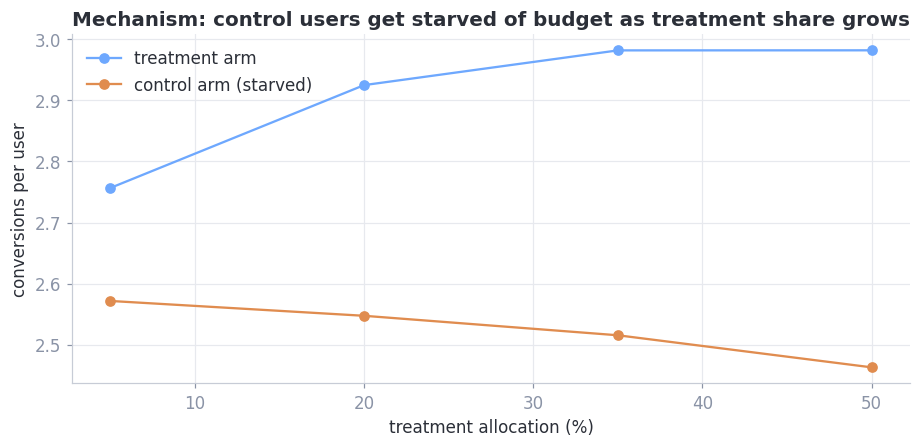

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(x, res.treat_conv, "-o", color=BLUE, label="treatment arm")
ax.plot(x, res.ctrl_conv, "-o", color=ORANGE, label="control arm (starved)")
ax.set_xlabel("treatment allocation (%)"); ax.set_ylabel("conversions per user")
ax.set_title("Mechanism: control users get starved of budget as treatment share grows")
ax.legend(); plt.tight_layout(); plt.show()

## 4. Act II — the fix, proven exactly (single-advertiser world)

Budget-split helps in the multi-advertiser market (below) but doesn't *fully* recover, because a
second channel remains — cross-advertiser effort substitution. To prove the correction is *right*,
isolate the budget channel: **one advertiser**, so there's nothing to substitute to. There,
budget-split recovers the true ATE exactly while naive stays biased.

isolated world: true ATE = -0.0408



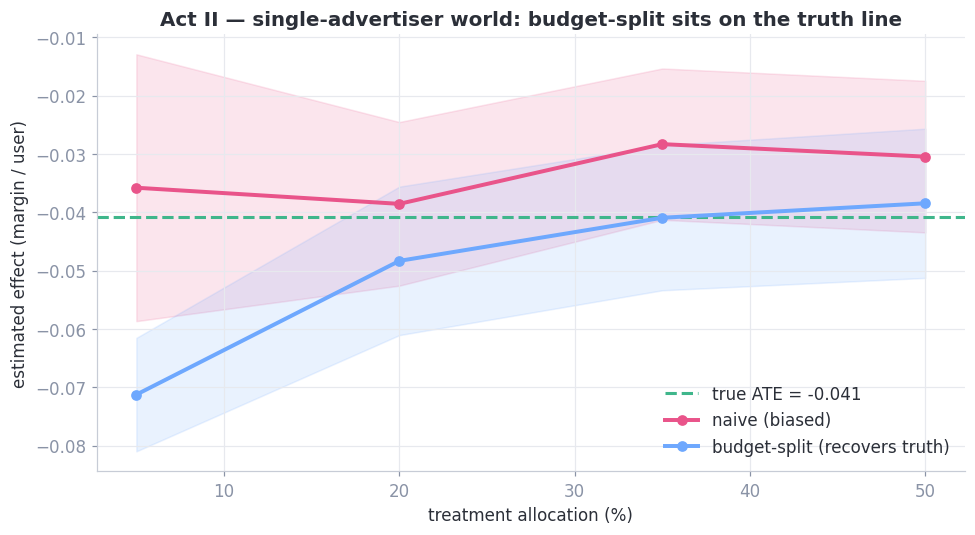

budget-split covers truth at: {'5%': False, '20%': True, '35%': True, '50%': True}


In [6]:
icfg = nbtools.iso_cfg(seed=3, users=8000, days=14)   # single advertiser, budget-only interference
igt = global_ate(icfg, EXP)
print(f"isolated world: true ATE = {igt.ate:+.4f}\n")
irows = []
for share in [0.05, 0.20, 0.35, 0.50]:
    run(nbtools.fixed_alloc(icfg, share, "standard"), output_dir="i_std", compute_tau=False)
    en = naive.estimate(user_outcomes("i_std", EXP))
    run(nbtools.fixed_alloc(icfg, share, "budget_split"), output_dir="i_bs", compute_tau=False)
    eb = budget_split.estimate(user_outcomes("i_bs", EXP))
    irows.append(dict(share=share, naive=en.point, naive_lo=en.ci_low, naive_hi=en.ci_high,
                      bs=eb.point, bs_lo=eb.ci_low, bs_hi=eb.ci_high,
                      naive_cov=en.covers(igt.ate), bs_cov=eb.covers(igt.ate)))
ires = pd.DataFrame(irows)

fig, ax = plt.subplots(figsize=(9, 5))
xi = ires.share * 100
ax.axhline(igt.ate, color=GREEN, ls="--", lw=2, label=f"true ATE = {igt.ate:+.3f}")
ax.fill_between(xi, ires.naive_lo, ires.naive_hi, color=PINK, alpha=0.15)
ax.plot(xi, ires.naive, "-o", color=PINK, lw=2.6, label="naive (biased)")
ax.fill_between(xi, ires.bs_lo, ires.bs_hi, color=BLUE, alpha=0.15)
ax.plot(xi, ires.bs, "-o", color=BLUE, lw=2.6, label="budget-split (recovers truth)")
ax.set_xlabel("treatment allocation (%)"); ax.set_ylabel("estimated effect (margin / user)")
ax.set_title("Act II — single-advertiser world: budget-split sits on the truth line")
ax.legend(loc="best"); plt.tight_layout(); plt.show()
print("budget-split covers truth at:",
      {f"{s:.0%}": bool(c) for s, c in zip(ires.share, ires.bs_cov)})

## 5. The honest summary

| world | naive bias @50% | budget-split bias @50% |
|---|---|---|
| multi-advertiser (2 channels) | large, grows with allocation | most removed, residual from effort substitution |
| single-advertiser (1 channel) | biased | **≈ 0 — recovers exactly** |

The naive estimator is wrong in a way that *looks* fine (tight CI, tiny p-value) but drifts from
truth; the corrected design recovers it when its assumption holds, and removes most of the bias even
when a second channel is present (motivating cluster designs, Phase 2). Next:
**`03_estimators_trust.py`** — the estimator zoo, the A/A nulls, and the ramp-selection confound.

In [7]:
import shutil
for d in ("events_std", "events_bs", "i_std", "i_bs"):
    shutil.rmtree(d, ignore_errors=True)